# Supply chain & inventory optimization — EDA

**Project:** End-to-end supply chain analytics portfolio project  
**Dataset:** DataCo Smart Supply Chain · 180,519 orders · January 2015 – January 2018  
**Author:** Ahmad Yasin  
**Tools:** Python · pandas · matplotlib · seaborn

---

## Project overview

This notebook is the starting point of an multi-section analytics project built on a 
real-world supply chain dataset. The goal is to translate raw transactional data 
into actionable inventory and operations insights.

**What this notebook covers:**
1. Initial data load and structural inspection
2. Data cleaning
3. Feature engineering
4. Exploratory visualisation

**Output:** A cleaned dataset (`supply_chain_clean.csv`) used by all subsequent notebooks.

---

## Notebook index

| Notebook | Section | Focus |
|----------|---------|-------|
| `01_data_exploration.ipynb` | 2 | Cleaning, EDA, visualisation |
| `02_sql_analysis.ipynb` | 3 | SQL queries, ABC classification |
| `03_forecasting.ipynb` | 4 | Demand forecasting with Prophet |
| `04_inventory_optimization.ipynb` | 5 | Safety stock, ROP, EOQ |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/DataCoSupplyChainDataset.csv', encoding='unicode_escape')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (180519, 53)

First 5 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [2]:
# See all 53 columns, their types, and where data is missing
print(df.info())

print("\nMissing values")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [3]:
df.columns = (df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_', regex=False)
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
    .str.replace('/', '_', regex=False))

print(df.columns.tolist())

['type', 'days_for_shipping_real', 'days_for_shipment_scheduled', 'benefit_per_order', 'sales_per_customer', 'delivery_status', 'late_delivery_risk', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_email', 'customer_fname', 'customer_id', 'customer_lname', 'customer_password', 'customer_segment', 'customer_state', 'customer_street', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_customer_id', 'order_date_dateorders', 'order_id', 'order_item_cardprod_id', 'order_item_discount', 'order_item_discount_rate', 'order_item_id', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_profit_per_order', 'order_region', 'order_state', 'order_status', 'order_zipcode', 'product_card_id', 'product_category_id', 'product_description', 'product_image', 'product_name', 'product_price', 'product_status', 'shipping_date_dateorders', 's

In [4]:
cols_to_drop = [
    'customer_password',
    'customer_email',
    'product_image',
    'product_description',
    'order_zipcode',
    'customer_street',
]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 47


In [5]:
# Convert date strings to actual datetime objects
df['order_date_dateorders'] = pd.to_datetime(df['order_date_dateorders'])
df['shipping_date_dateorders'] = pd.to_datetime(df['shipping_date_dateorders'])

# Fill the small number of remaining null zip codes with 'Unknown'
if 'customer_zipcode' in df.columns:
    df['customer_zipcode'] = df['customer_zipcode'].fillna('Unknown')

print("Date types confirmed:")
print(df[['order_date_dateorders', 'shipping_date_dateorders']].dtypes)
print(f"\nAny nulls left: {df.isnull().sum().sum()}")

Date types confirmed:
order_date_dateorders       datetime64[ns]
shipping_date_dateorders    datetime64[ns]
dtype: object

Any nulls left: 8


In [6]:
# Time features
df['order_year']      = df['order_date_dateorders'].dt.year
df['order_month']     = df['order_date_dateorders'].dt.month
df['order_month_name']= df['order_date_dateorders'].dt.strftime('%b')
df['order_week']      = df['order_date_dateorders'].dt.isocalendar().week.astype(int)
df['order_dayofweek'] = df['order_date_dateorders'].dt.day_name()

# Shipping performance
# Positive = arrived late, Negative = arrived early
df['shipping_delay'] = df['days_for_shipping_real'] - df['days_for_shipment_scheduled']

# Profitability
df['profit_margin'] = (
    df['benefit_per_order'] / df['sales_per_customer'].replace(0, np.nan)
).round(4)

# Stockout/overstock proxy
# Orders where discount > 30% suggest overstocked items being cleared
df['is_heavily_discounted'] = (df['order_item_discount_rate'] > 0.3).astype(int)

print("New features created:")
print(df[['order_year','order_month','shipping_delay','profit_margin','is_heavily_discounted']].head())

New features created:
   order_year  order_month  shipping_delay  profit_margin  \
0        2018            1              -1          0.290   
1        2018            1               1         -0.800   
2        2018            1               0         -0.800   
3        2018            1              -1          0.075   
4        2018            1              -2          0.450   

   is_heavily_discounted  
0                      0  
1                      0  
2                      0  
3                      0  
4                      0  


In [7]:
df.to_csv('../data/supply_chain_clean.csv', index=False)
print(f"Saved! Shape: {df.shape}")
print(f"Date range: {df['order_date_dateorders'].min().date()} → {df['order_date_dateorders'].max().date()}")

Saved! Shape: (180519, 55)
Date range: 2015-01-01 → 2018-01-31


## Late delivery rate by shipping mode

We investigate whether shipping mode correlates with delivery reliability.
The expectation is that premium (faster) shipping modes would have lower late rates.

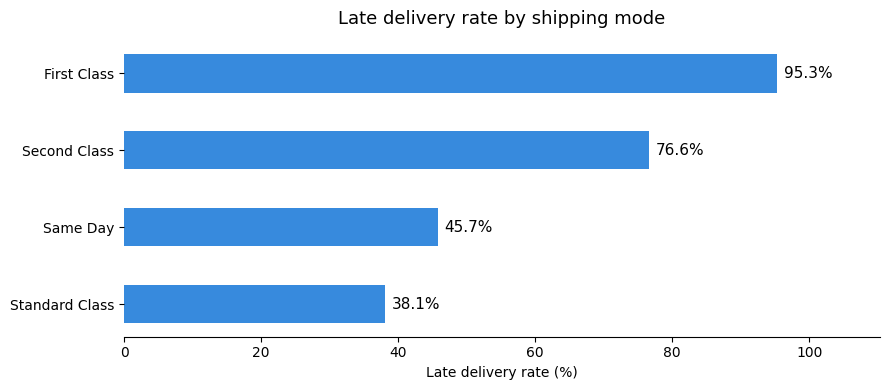

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))

late_by_mode = (df.groupby('shipping_mode')['late_delivery_risk']
                  .mean()
                  .mul(100)
                  .sort_values())

bars = ax.barh(late_by_mode.index, late_by_mode.values, color='#378ADD', height=0.5)
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=11)
ax.set_xlabel('Late delivery rate (%)')
ax.set_title('Late delivery rate by shipping mode', fontsize=13, pad=12)
ax.spines[['top','right','left']].set_visible(False)
ax.set_xlim(0, late_by_mode.max() + 15)
plt.tight_layout()
plt.savefig('../outputs/late_delivery_by_mode.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding 1: Premium shipping is paradoxically the least reliable

First Class shipping has a **95.3% late delivery rate** which is the worst of all four modes,
despite being the premium tier. Standard Class (38.1%) is the most reliable.

**Business implication:** The company is systematically failing to meet delivery 
commitments on its highest-tier service. Customers paying a premium for speed 
are being let down more than standard customers. This warrants an immediate audit 
of First Class SLA windows and carrier contracts.

## Monthly order volume over time (Jan 2015 – Jan 2018)

We examine order volume trends across the full dataset to identify seasonality,
growth patterns, or operational disruptions.

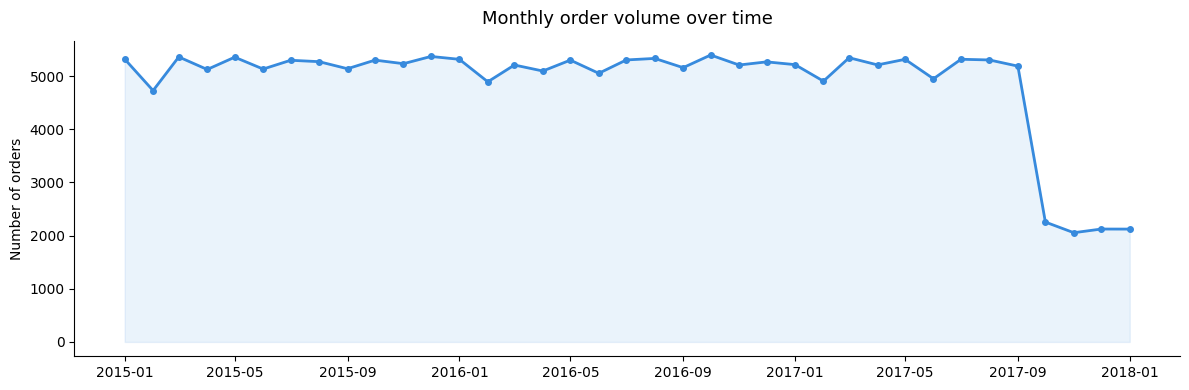

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))

monthly = (df.groupby(['order_year','order_month'])
             .size()
             .reset_index(name='order_count'))
monthly['period'] = pd.to_datetime(
    monthly['order_year'].astype(str) + '-' + monthly['order_month'].astype(str), 
    format='%Y-%m'
)

ax.plot(monthly['period'], monthly['order_count'], color='#378ADD', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly['period'], monthly['order_count'], alpha=0.1, color='#378ADD')
ax.set_title('Monthly order volume over time', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Number of orders')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/monthly_order_volume.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding 2: Flat volume with a data truncation anomaly in late 2017

Order volume is remarkably consistent at ~5,100–5,300 orders/month from 
January 2015 through August 2017, with no significant seasonal pattern.

A sharp drop to ~2,100 orders/month occurs from September 2017 onward. 
This is not a business event. It is a known data truncation artifact 
where the dataset was not fully recorded for the final months.

**Analytical implication:** Forecasting models will be trained on 
January 2015 – August 2017 only. The truncated months are excluded to prevent 
bias in demand predictions.

## Top 10 product categories by total revenue

We rank categories by cumulative revenue across the full period to identify 
the core business and prioritise inventory focus areas.

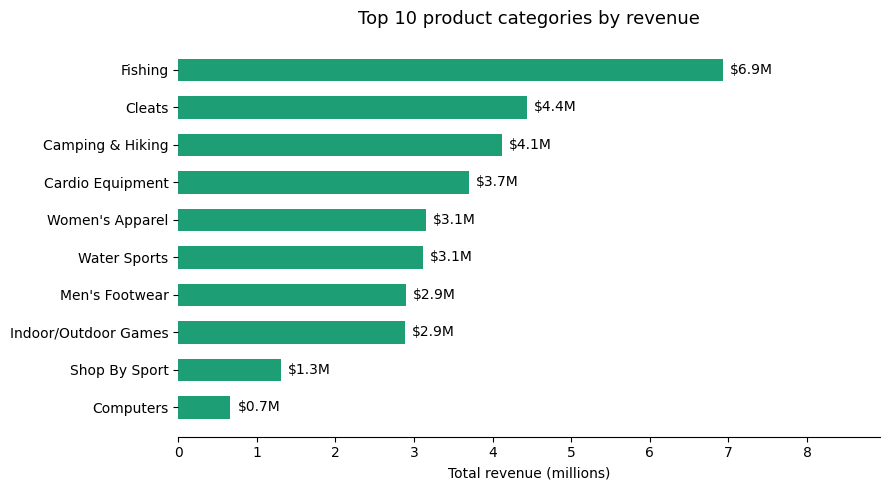

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

top_cats = (df.groupby('category_name')['sales']
              .sum()
              .sort_values(ascending=True)
              .tail(10))

bars = ax.barh(top_cats.index, top_cats.values / 1e6, color='#1D9E75', height=0.6)
ax.bar_label(bars, fmt='$%.1fM', padding=5, fontsize=10)
ax.set_xlabel('Total revenue (millions)')
ax.set_title('Top 10 product categories by revenue', fontsize=13, pad=12)
ax.spines[['top','right','left']].set_visible(False)
ax.set_xlim(0, top_cats.max() / 1e6 + 2)
plt.tight_layout()
plt.savefig('../outputs/top_categories_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

### Finding 3: Fishing dominates; Computers is a non-core outlier

Fishing ($6.9M) leads all categories by a significant margin — 57% more revenue 
than second-place Cleats ($4.4M). The top four categories (Fishing, Cleats, 
Camping & Hiking, Cardio Equipment) are all outdoor/sports, confirming the 
company's core market positioning.

Computers ($0.7M) is a clear outlier. Low revenue in a non-core vertical, 
suggesting either a test category or a candidate for divestment.

**Business implication:** Inventory optimization efforts should prioritise the 
top 5 categories, where stockout risk carries the highest revenue consequence.

---

## Key findings

| # | Finding | Business implication |
|---|---------|----------------------|
| 1 | First Class shipping has a 95.3% late delivery rate | Audit SLA commitments for premium tiers |
| 2 | Order volume is flat ~5,200/month with no seasonality | Operational consistency; data truncated from Sep 2017 |
| 3 | Fishing leads revenue at $6.9M — 57% above #2 | Concentrate inventory focus on top 5 categories |

**Dataset:** DataCo Smart Supply Chain · 180,519 orders · Jan 2015 – Jan 2018  
**Tools used:** Python · pandas · matplotlib · seaborn